In [1]:
# Load XY dataset and metadata produced by the simulator
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Path to the compressed dataset produced by build_xy_dataset
DATA_PATH = Path('gxy_dataset.npz')
METADATA_PATH = Path('gxy_dataset.metadata.json')

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset {DATA_PATH} not found. Update DATA_PATH to point to your file.")
if not METADATA_PATH.exists():
    raise FileNotFoundError(f"Metadata file {METADATA_PATH} not found.")

with np.load(DATA_PATH) as npz:
    configurations = npz['configurations']

with open(METADATA_PATH, 'r', encoding='utf-8') as f:
    metadata = json.load(f)

num_samples, num_sites = configurations.shape
print(f"Loaded {num_samples} samples with {num_sites} lattice sites each.")

Loaded 400 samples with 256 lattice sites each.


Loaded 400 samples with 256 lattice sites each.
Unique (T,delta) points: 400
Cluster sizes: [ 96 169 135]
Silhouette score (on centroids): 0.652


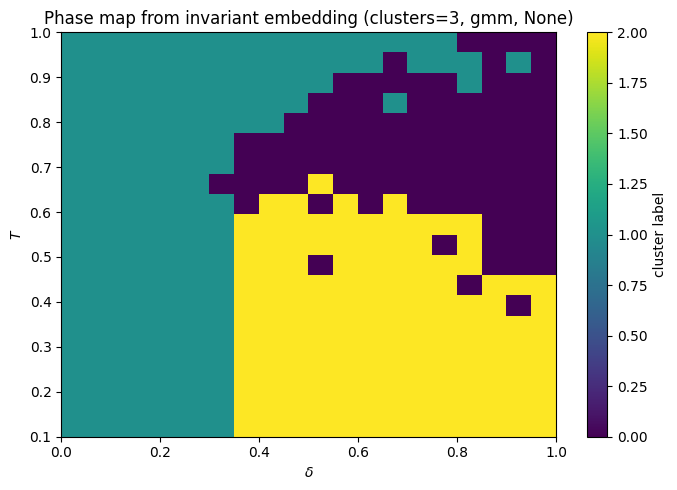

In [9]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from kernal import (
    projected_kernel_o2,
    degree_from_W0,
    symmetric_normalize,
    build_invariant_embedding,
    phase_map_from_invariant_embedding,
)


# Path to the compressed dataset produced by build_xy_dataset
DATA_PATH = Path('gxy_dataset.npz')
METADATA_PATH = Path('gxy_dataset.metadata.json')

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset {DATA_PATH} not found. Update DATA_PATH to point to your file.")
if not METADATA_PATH.exists():
    raise FileNotFoundError(f"Metadata file {METADATA_PATH} not found.")

with np.load(DATA_PATH) as npz:
    configurations = npz['configurations']

with open(METADATA_PATH, 'r', encoding='utf-8') as f:
    metadata = json.load(f)

num_samples, num_sites = configurations.shape
print(f"Loaded {num_samples} samples with {num_sites} lattice sites each.")

W_0 = projected_kernel_o2(configurations, 100, 0)
W_1 = projected_kernel_o2(configurations, 100, 1)
W_2 = projected_kernel_o2(configurations, 100, 2)
D = degree_from_W0(W_0)
S_0 = symmetric_normalize(W_0, D)
S_1 = symmetric_normalize(W_1, D)
S_2 = symmetric_normalize(W_2, D)

S_m = {0: S_0, 1: S_1, 2: S_2}
Psi, eigs = build_invariant_embedding(S_m, K=1, t=1, skip_first=False, assume_hermitian=True, diagonal_only=False)

temperatures = np.array([entry['temperature'] for entry in metadata], dtype=np.float64)
deltas = np.array([entry['delta'] for entry in metadata], dtype=np.float64)

phase_map, T_grid, D_grid, labels_param, centroids, uniq_pairs = phase_map_from_invariant_embedding(
Psi,
temperatures,
deltas,
n_clusters=3,
reducer=None,
n_components=30,
clusterer="gmm",     # try "kmeans" too
random_state=0,
make_plot=True,
)

In [10]:
# Only if these keys exist in metadata
if "magnetization" in metadata[0] and ("nematic" in metadata[0] or "Q" in metadata[0]):
    M = np.array([entry["magnetization"] for entry in metadata], dtype=np.float64)
    Q = np.array([entry.get("nematic", entry.get("Q")) for entry in metadata], dtype=np.float64)

    # sample -> param cluster label
    pairs = np.stack([np.round(temperatures, 8), np.round(deltas, 8)], axis=1)
    uniq_pairs2, inv = np.unique(pairs, axis=0, return_inverse=True)
    labels_samples = labels_param[inv]

    for c in range(3):
        mask = labels_samples == c
        print(f"Cluster {c}: mean|M|={M[mask].mean():.3f}, mean|Q|={Q[mask].mean():.3f}, n={mask.sum()}")


Cluster 0: mean|M|=0.798, mean|Q|=0.482, n=96
Cluster 1: mean|M|=0.175, mean|Q|=0.670, n=169
Cluster 2: mean|M|=0.950, mean|Q|=0.825, n=135
